In [ ]:

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import numpy as np

In [ ]:
(X_train,y_train),(X_test,y_test)=keras.datasets.mnist.load_data()

In [ ]:
len(X_train)

60000

In [ ]:
len(X_test)

10000

In [ ]:
X_train[0].shape

(28, 28)

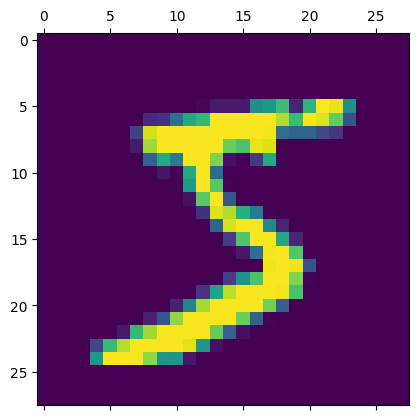

In [ ]:
plt.matshow(X_train[0])

In [ ]:
y_train[0]

5

In [ ]:
X_train=X_train/225
X_test=X_test/225

In [ ]:
X_train_flattened=X_train.reshape(len(X_train),28*28)
X_test_flattened=X_test.reshape(len(X_test),28*28)

In [ ]:
X_train_flattened.shape

(60000, 784)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(X_train,y_train,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9270 - loss: 0.2518
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9677 - loss: 0.1096
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9774 - loss: 0.0744
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9827 - loss: 0.0556
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9871 - loss: 0.0426


In [ ]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9752 - loss: 0.0789


[0.07887240499258041, 0.9751999974250793]

In [ ]:
model.export("saved_model")

Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  134465369311376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134465369312144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134465369311568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134465369312336: TensorSpec(shape=(), dtype=tf.resource, name=None)


**1.Post training quantization**

In [ ]:
#without quantization
converter = tf.lite.TFLiteConverter.from_saved_model("saved_model")
tflite_model = converter.convert()

In [ ]:
len(tflite_model)

320688

In [ ]:
#with quantization
converter=tf.lite.TFLiteConverter.from_saved_model("saved_model")
converter.optimizations=[tf.lite.Optimize.DEFAULT]
tflite_quant_model=converter.convert()

In [ ]:
len(tflite_model)

320688

In [ ]:
len(tflite_quant_model)

86752

In [ ]:
with open("tflite_model.tflite","wb") as f:
  f.write(tflite_model)

In [ ]:
with open("tflite_quant_model.tflite","wb") as f:
  f.write(tflite_quant_model)

**Quantization aware training**

In [ ]:
!pip install tensorflow-model-optimization

In [ ]:
import tensorflow as tf

# Convert model to TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Apply quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# Save
with open("model_quant.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpim3i9nlc'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  134465369311376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134465369312144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134465369311568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134465369312336: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
model.build(input_shape=(None, 28, 28))

In [ ]:
print(type(model))
print(model.built)

<class 'keras.src.models.sequential.Sequential'>
True


**Quantization dont work with the current tensorflow version**

# Task
Fix the TFLite model conversion by using `tf.lite.TFLiteConverter.from_keras_model` with the existing `model` object.

## fix_tflite_conversion

### Subtask:
Change the TFLite converter method to `tf.lite.TFLiteConverter.from_keras_model` to directly convert the Keras model object instead of trying to load it from a .keras file as a SavedModel.


## Summary:

### Data Analysis Key Findings
- The original TFLite conversion method was attempting to load the model from a `.keras` file as a SavedModel, which was identified as an incorrect approach.
- The correct method for TFLite conversion was determined to be directly using the existing Keras model object with `tf.lite.TFLiteConverter.from_keras_model`.

### Insights or Next Steps
- Directly converting the Keras model object simplifies the TFLite conversion process and avoids potential issues associated with loading from a `.keras` file.
- The next step is to implement this change in the TFLite converter to ensure a successful and robust conversion of the Keras model into a TFLite format.
